## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Predicting Mental Health Treatment from Workplace Factors

## 🎯 Objective

This project builds a machine learning model to predict whether an employee seeks mental health treatment based on workplace factors.

The analysis is framed as a binary classification problem, where the target variable is `treatment` (Yes / No).

Beyond prediction, the goal is to identify which workplace conditions are most strongly associated with treatment-seeking behavior.

This allows us to extract insights about how workplace environment and support influence mental health decisions.

## 📂 Loading the dataset

The dataset used in this project is the Survey on Mental Health in the Tech Workplace in 2014, retrieved from: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey?resource=download*

In [2]:
file_path = "mental_health_in_tech_survey.csv"
data = pd.read_csv(file_path)

data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")
data.head()

,timestamp,age,gender,country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 🔍 Data Overview

The dataset contains survey responses from tech workers regarding mental health.

Target variable:
- `treatment`: whether the respondent sought mental health treatment (Yes/No)

Predictors focus on workplace-related factors such as:
- `benefits`
- `anonymity`
- `supervisor support`
- `wellness programs`

The dataset is primarily composed of categorical variables and contains some missing values that will be handled in the preprocessing section. 

## 🎯 Feature Selection

Only workplace-related variables are included as predictors.

This keeps the modeling task aligned with the research question:
can workplace conditions and perceived support predict whether someone seeks treatment?

Personal variables such as age, gender, and family history are excluded here to focus specifically on workplace context.

In [3]:
target = "treatment"

selected_features = [
    "remote_work",
    "tech_company",
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave",
    "mental_health_consequence",
    "phys_health_consequence",
    "coworkers",
    "supervisor",
    "mental_health_interview",
    "phys_health_interview",
    "mental_vs_physical",
    "obs_consequence",
    "no_employees",
    "self_employed",
    "work_interfere"
]

df = data[selected_features + [target]].copy()
df.head()

,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,no_employees,self_employed,work_interfere,treatment
0,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,6-25,NaN,Often,Yes
1,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,More than 1000,NaN,Rarely,No
2,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,6-25,NaN,Rarely,No
3,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,26-100,NaN,Often,Yes
4,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,100-500,NaN,Never,No


## 🧹 Data Cleaning

The target variable is converted to binary form.  Rows with invalid or missing target values are filtered out.  
Missing values in predictor variables are handled within the preprocessing pipeline using imputation.

In [4]:
df = df[df[target].isin(["Yes", "No"])].copy()
df[target] = df[target].map({"Yes": 1, "No": 0})

print(df.shape)
df[target].value_counts(normalize=True)

(1259, 20)


treatment
1    0.505957
0    0.494043
Name: proportion, dtype: float64

## 🔍 Missing Values Overview

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

work_interfere    264
self_employed      18
dtype: int64

In [6]:
categorical_cols = df.drop(columns=[target]).columns.tolist()

## ✂️ Train/Test Split

The dataset is split into training and test sets (80/20).

Stratification is applied to preserve the original class distribution of the target variable in both sets, ensuring a balanced evaluation.

In [7]:
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1007, 19) (252, 19)


## ⚙️ Preprocessing

Categorical variables are handled through a preprocessing pipeline.

Missing values are filled using the most frequent category, which works well for categorical data.  
Features are then one-hot encoded to convert them into a numerical format without imposing any artificial order.  
Unknown categories are ignored to make the model more robust when encountering new data.


In [8]:
categorical_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

## 🤖 Modeling Strategy

Two models are used:

- **Logistic Regression** for interpretability
- **Random Forest** for non-linear relationships and more flexible decision boundaries

Class imbalance is handled with SMOTE inside the training pipelines.

## 📈 Logistic Regression

In [9]:
logreg_pipeline = ImbPipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    logreg_pipeline,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_lr.best_params_)
print("Best Logistic Regression CV ROC AUC:", round(grid_lr.best_score_, 3))

Best Logistic Regression Params: {'classifier__C': 0.1}
Best Logistic Regression CV ROC AUC: 0.768


## 🌲 Random Forest

In [10]:
rf_pipeline = ImbPipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Random Forest Params:", grid_rf.best_params_)
print("Best Random Forest CV ROC AUC:", round(grid_rf.best_score_, 3))

Best Random Forest Params: {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best Random Forest CV ROC AUC: 0.786


## 📊 Test Set Evaluation

In [11]:
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{name}")
    print("-" * len(name))
    print("ROC AUC:", round(auc, 3))
    print(classification_report(y_test, y_pred))


Logistic Regression
-------------------
ROC AUC: 0.802
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       124
           1       0.78      0.69      0.73       128

    accuracy                           0.74       252
   macro avg       0.75      0.74      0.74       252
weighted avg       0.75      0.74      0.74       252


Random Forest
-------------
ROC AUC: 0.786
              precision    recall  f1-score   support

           0       0.68      0.77      0.72       124
           1       0.75      0.65      0.69       128

    accuracy                           0.71       252
   macro avg       0.71      0.71      0.71       252
weighted avg       0.71      0.71      0.71       252



## 🏆 Model Selection

Logistic Regression is selected as the final model due to its slightly better ROC AUC on the test set and its higher interpretability.

Although Random Forest achieved a higher cross-validation ROC AUC, Logistic Regression performed better on unseen data, suggesting better generalization.

## 🧩 Confusion Matrix

Best model: Logistic Regression


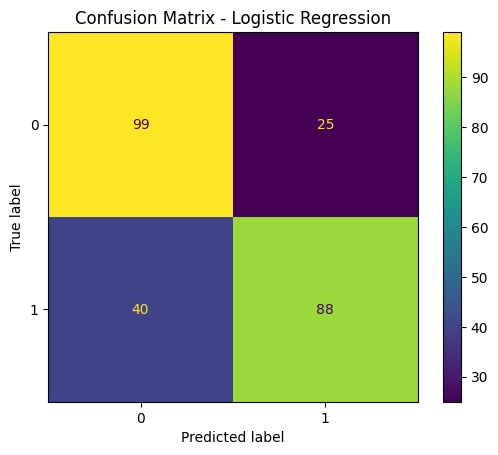

In [12]:
best_model_name = max(
    models,
    key=lambda name: roc_auc_score(y_test, models[name].predict_proba(X_test)[:, 1])
)
best_model = models[best_model_name]

print("Best model:", best_model_name)

y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

#### 🧩 Interpretation

The confusion matrix shows how the model performs in terms of correct and incorrect predictions.

- True Negatives (99): correctly identified employees who did not seek treatment  
- True Positives (88): correctly identified employees who sought treatment  
- False Positives (25): predicted treatment when it was not the case  
- False Negatives (40): missed employees who actually sought treatment  

The model makes more false negatives than false positives, meaning it tends to miss some employees who may need support.

In a mental health context, this is important because failing to identify someone in need (false negative) may be more costly than incorrectly flagging someone.

## 📉 ROC Curve Comparison

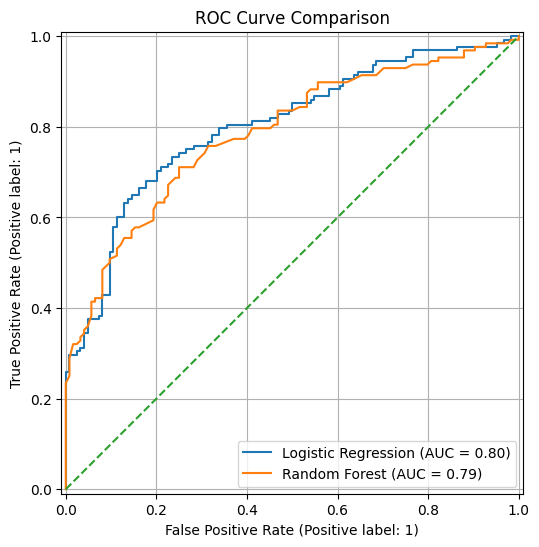

In [13]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

#### 📉 Interpretation

The ROC curve compares the performance of Logistic Regression and Random Forest across different classification thresholds.

Both models perform significantly better than random guessing (diagonal line), indicating that they capture meaningful patterns in the data.

Logistic Regression slightly outperforms Random Forest, with a higher ROC AUC (≈ 0.80 vs 0.79), confirming its better overall ability to distinguish between employees who seek treatment and those who do not.

This supports the decision to select Logistic Regression as the final model.

## 🎯 Threshold Tuning & Business Perspective

In a workplace mental health context, missing employees who need support (false negatives) can be more costly than incorrectly flagging someone (false positives).

Instead of using the default threshold of 0.5, the threshold is adjusted to increase recall for the positive class (treatment = 1).

The threshold defines the probability cutoff above which an observation is classified as positive. Lowering it leads to more positive predictions, increasing recall but reducing precision.

In this case, the threshold is lowered to identify more employees who may need support, accepting a higher number of false positives.

In [14]:
# Getting probabilities from the best model
y_proba = best_model.predict_proba(X_test)[:, 1]

# Computing the precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)


threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df.head()

,threshold,precision,recall
0,0.089862,0.507937,1.000000
1,0.100142,0.509960,1.000000
2,0.100904,0.512000,1.000000
3,0.111082,0.510040,0.992188
4,0.128564,0.512097,0.992188


In [15]:
# Selecting threshold targeting higher recall (to reduce false negatives)
target_recall = 0.80

best_threshold = threshold_df.iloc[(threshold_df["recall"] - target_recall).abs().argsort()[:1]]["threshold"].values[0]

best_threshold

np.float64(0.41802546896765863)

In [16]:
# Applying the new threshold
y_pred_custom = (y_proba >= best_threshold).astype(int)

print("Custom threshold:", round(best_threshold, 3))
print(classification_report(y_test, y_pred_custom))

Custom threshold: 0.418
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       124
           1       0.70      0.80      0.74       128

    accuracy                           0.72       252
   macro avg       0.73      0.72      0.72       252
weighted avg       0.73      0.72      0.72       252



In [17]:
print("Default threshold (0.5):")
print(classification_report(y_test, best_model.predict(X_test)))
    
print("\nCustom threshold:")
print(classification_report(y_test, y_pred_custom))

Default threshold (0.5):
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       124
           1       0.78      0.69      0.73       128

    accuracy                           0.74       252
   macro avg       0.75      0.74      0.74       252
weighted avg       0.75      0.74      0.74       252


Custom threshold:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       124
           1       0.70      0.80      0.74       128

    accuracy                           0.72       252
   macro avg       0.73      0.72      0.72       252
weighted avg       0.73      0.72      0.72       252



### 🧠 Interpretation

Changing the decision threshold modifies how the model's behavior.

By default, scikit-learn uses a threshold of 0.5 to convert predicted probabilities into class labels: observations with a predicted probability ≥ 0.5 are classified as positive.

With this default threshold, the model has higher precision but lower recall for the positive class (treatment = 1), meaning it misses more employees who may need support.

By lowering the threshold, recall increases from 0.69 to 0.80, so the model identifies more individuals likely to seek mental health treatment.

This comes at the cost of lower precision (0.78 → 0.70) and a small drop in overall accuracy.

In this context, this trade-off makes sense: missing someone who needs support (false negative) is more problematic than incorrectly flagging someone (false positive).

This shows that model performance should match real-world priorities, rather than relying only on default settings.

To understand which variables matter most in the model, we now look at feature importance.

## 🔎 Feature Importance

Since Logistic Regression performed best overall, feature importance is interpreted using its coefficients.

For one-hot encoded categorical variables:

- positive coefficients increase the likelihood of seeking treatment  
- negative coefficients decrease the likelihood of seeking treatment  

To make this easier to read, the features with the largest absolute coefficients are shown below.

In [18]:
# Getting the fitted logistic regression classifier
logreg_clf = best_lr.named_steps["classifier"]

# Getting feature names after preprocessing
onehot = best_lr.named_steps["preprocessing"].named_transformers_["cat"].named_steps["onehot"]
feature_names = onehot.get_feature_names_out(categorical_features)

# Extracting the coefficients
coefficients = logreg_clf.coef_[0]

# Building the coefficient table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Keeping the 15 most important features
top_coef = (
    coef_df.sort_values("abs_coefficient", ascending=False)
           .head(15)
           .sort_values("coefficient")
)

top_coef

,feature,coefficient,abs_coefficient
55,work_interfere_Never,-1.265955,1.265955
30,coworkers_No,-0.421018,0.421018
25,mental_health_consequence_No,-0.316659,0.316659
8,care_options_Not sure,-0.293677,0.293677
5,benefits_No,-0.252259,0.252259
52,no_employees_More than 1000,-0.221836,0.221836
45,obs_consequence_No,-0.221682,0.221682
46,obs_consequence_Yes,0.221820,0.221820
26,mental_health_consequence_Yes,0.225796,0.225796
20,leave_Somewhat difficult,0.335248,0.335248


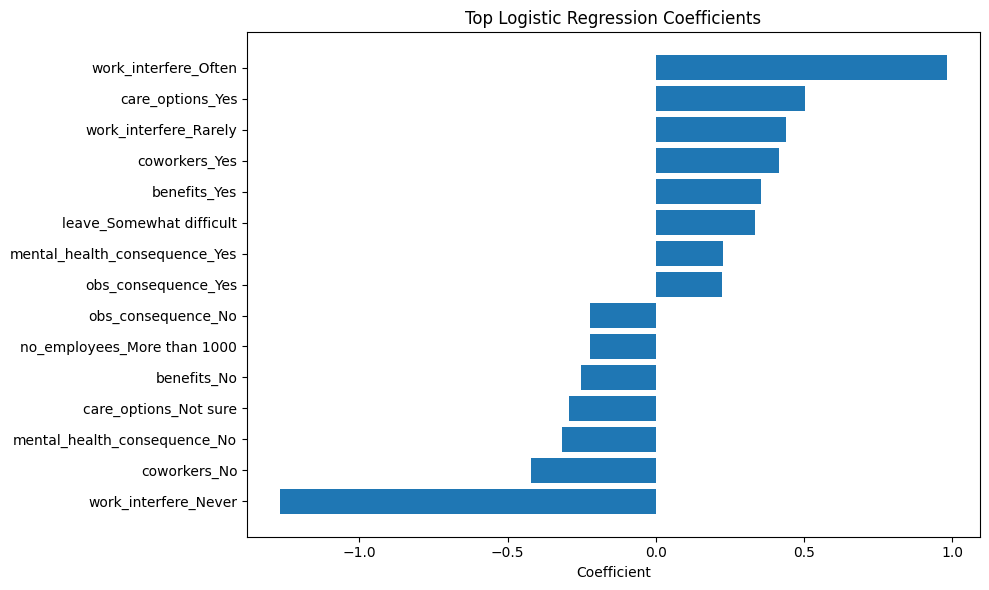

In [19]:
plt.figure(figsize=(10, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [20]:
# Sorting the coefficients by their absolute magnitude 
top_coef_sorted = top_coef.sort_values(
    by="coefficient",
    key=lambda x: x.abs(),
    ascending=False
)[["feature", "coefficient"]].reset_index(drop=True)

top_coef_sorted

,feature,coefficient
0,work_interfere_Never,-1.265955
1,work_interfere_Often,0.980821
2,care_options_Yes,0.502285
3,work_interfere_Rarely,0.440448
4,coworkers_No,-0.421018
5,coworkers_Yes,0.414348
6,benefits_Yes,0.355468
7,leave_Somewhat difficult,0.335248
8,mental_health_consequence_No,-0.316659
9,care_options_Not sure,-0.293677


## 🧠 Interpretation

The strongest positive predictors of treatment-seeking are:

- mental health interfering with work  
- having clear access to care options  
- having workplace benefits  
- being able to talk about mental health with coworkers  

The strongest negative predictors are:

- no impact of mental health on work  
- lack of coworker support  
- lack of benefits  
- uncertainty about available care options  

Overall, two main factors explain most of the behavior:

**1. Perceived need**  
Employees whose mental health affects their work are much more likely to seek treatment. This is the strongest signal in the model.

**2. Workplace support and clarity**  
When employees know what support is available and feel comfortable talking about mental health, they are more likely to seek help. On the other hand, uncertainty reduces that likelihood.

This shows that both personal experience and workplace environment play a role in treatment decisions.


## 🧩 Business Recommendations

Based on the model insights, organizations should focus on:

**1. Identifying employees struggling with work interference**  
Employees who report that mental health affects their work are the most likely to need support.

**2. Making access to care clear and visible**  
Providing clear information about care options and benefits increases the likelihood of seeking help.

**3. Creating an environment where people can talk openly**  
When employees feel comfortable discussing mental health, they are more likely to seek support.

**4. Reducing fear around disclosure**  
Employees should not feel that speaking up about mental health will have negative consequences.

These actions can improve employee well-being and reduce long-term productivity loss.

## ⚠️ Limitations

A few limitations should be kept in mind:

**Self-reported data**  
The dataset comes from survey responses, which may include bias (e.g., underreporting or socially desirable answers).

**Missing data**  
Some variables contain missing values that were imputed, which may introduce noise.

**High dimensionality after encoding**  
One-hot encoding increases the number of features, which can make interpretation harder.

**Correlation vs causation**  
The model shows relationships, not cause and effect.

**Dataset scope**  
The data comes from a tech-focused survey, so results may not generalize to other industries.


## ✅ Conclusion

Workplace conditions are strong indicators of whether employees seek mental health support.

The model performs well (ROC AUC ≈ 0.80), but more importantly, it highlights two key drivers:
- perceived impact of mental health on work
- access to support and workplace environment

This shows that improving clarity, support, and workplace culture can directly influence treatment-seeking behavior.

## 🚀 From Analysis to Production

To use this project in a real setting:

**1. Data**  
Collect data regularly (e.g. internal surveys) and make sure it’s clean and consistent.

**2. Pipeline**  
Deploy the full pipeline (preprocessing + model) and expose predictions through an API (like FastAPI).

**3. Monitoring**  
Track performance over time and watch for changes in the data.

**4. Ethics**  
Protect sensitive data and use predictions to support employees, not penalize them.


## 📤 Sample export for GitHub preview

In [22]:
df_sample = df.sample(50, random_state=42)
df_sample.to_csv("sample.csv", index=False)